In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Testing_data 09 11 2025")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
INPUT_FILE = '/content/drive/MyDrive/Testing_data 09 11 2025/final_coastdown_curve.csv'  # Output from Step 4

# Car Parameters (FILL THESE IN)
MASS_KG = 250.0        # Total Mass (Car + Driver)
FRONTAL_AREA_M2 = 1.2  # Frontal Area (m^2)

# Air Density @ 27°C (Hardcoded)
RHO_AIR = 1.176        # kg/m^3

In [ ]:
def get_drag_coefficient():
    print(f"--- Formula Student Drag Calculator ---")
    print(f"Environment: 27°C, Air Density = {RHO_AIR} kg/m^3")
    print(f"Car: {MASS_KG} kg, {FRONTAL_AREA_M2} m^2")

    # 1. Load Data
    df = pd.read_csv(INPUT_FILE)

    # X = Velocity (m/s), Y = Deceleration (m/s^2)
    # We filter for speed > 3 m/s to remove low-speed noise
    mask = df['Velocity_Kalman'] > 3.0
    v_data = df.loc[mask, 'Velocity_Kalman']
    a_data = df.loc[mask, 'Accel_Kalman']

    # 2. Fit Polynomial: a = K*v^2 + B*v + C
    # We use a 2nd degree polynomial.
    # The coefficient of v^2 (index 0) captures the Aerodynamic Drag.
    coeffs = np.polyfit(v_data, a_data, 2)

    K = coeffs[0]  # This is the coefficient of v^2
    B = coeffs[1]
    C = coeffs[2]

    print(f"\nFitted Motion Equation: a(v) = ({K:.5f})v^2 + ({B:.5f})v + ({C:.5f})")

    # 3. Calculate Cd
    # Drag Force Fd = 0.5 * rho * A * Cd * v^2
    # Decel from Drag = Fd / m = (0.5 * rho * A * Cd / m) * v^2
    # Therefore: K = -(0.5 * rho * A * Cd / m)
    # Solving for Cd:
    # Cd = (2 * m * |K|) / (rho * A)

    # We use abs(K) because deceleration K is negative
    Cd = (2 * MASS_KG * abs(K)) / (RHO_AIR * FRONTAL_AREA_M2)

    print("\n" + "="*30)
    print(f"  CALCULATED Cd: {Cd:.4f}")
    print("="*30)

    # 4. Plotting
    plt.figure(figsize=(10, 6))

    # Raw Kalman Points
    plt.scatter(v_data, a_data, color='black', s=2, alpha=0.3, label='Test Data')

    # Fitted Curve
    v_fit = np.linspace(v_data.min(), v_data.max(), 100)
    a_fit = np.polyval(coeffs, v_fit)

    plt.plot(v_fit, a_fit, 'r-', linewidth=3, label=f'Poly Fit (Cd={Cd:.3f})')

    plt.title(f"Coast Down: Aerodynamic Fit (Cd = {Cd:.3f})")
    plt.xlabel("Velocity (m/s)")
    plt.ylabel("Deceleration (m/s^2)")
    plt.legend()
    plt.grid(True)
    plt.show()

--- Formula Student Drag Calculator ---
Environment: 27°C, Air Density = 1.176 kg/m^3
Car: 250.0 kg, 1.2 m^2

Fitted Motion Equation: a(v) = (2.01642)v^2 + (-38.56244)v + (182.14128)

  CALCULATED Cd: 714.4338


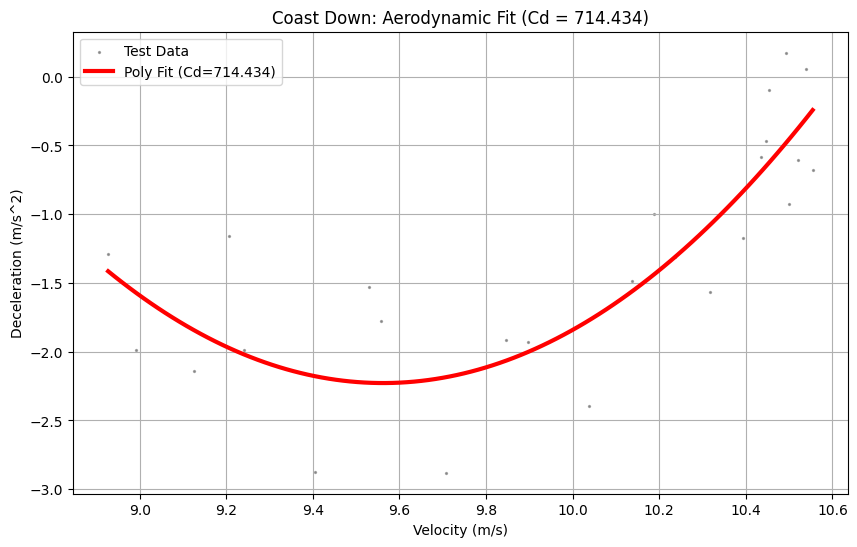

In [ ]:
get_drag_coefficient()